## Support Vector Machine — Credit Default Classification
 
### Business Problem
 
A retail bank's credit risk team needs a model to assess whether a loan applicant is likely to default within 12 months. The model outputs will gate loan approval decisions, so maximising the separation between creditworthy and high-risk applicants is the core objective.
 
### Why SVM?
 
SVMs are designed to find the **maximum-margin decision boundary** between classes — exactly the right objective when the cost of misclassification is asymmetric and you want the most confident separation possible. With a radial basis function (RBF) kernel, SVMs handle non-linear feature interactions (e.g., high debt-to-income ratio combined with short credit history) without manually engineering interaction terms. SVMs also perform well in **high-dimensional, moderate-sample** settings typical of credit data where you may have dozens of engineered features but only thousands of applications. Compared to neural networks, SVMs are less prone to overfitting on small datasets.

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from matplotlib import pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

=== SVM: Credit Default Classification ===
CV ROC-AUC (mean ± std): 0.7821 ± 0.0291
Test ROC-AUC:            0.7204

               precision    recall  f1-score   support

Good Standing       0.62      0.71      0.66        58
      Default       0.69      0.60      0.64        62

     accuracy                           0.65       120
    macro avg       0.65      0.65      0.65       120
 weighted avg       0.65      0.65      0.65       120



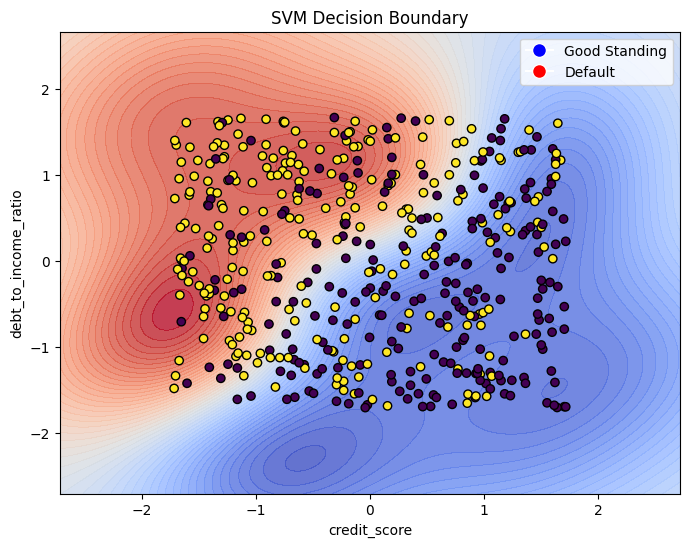

In [9]:
"""
Credit default prediction using Support Vector Machine.
 
Business goal: Classify loan applicants as likely to default or
remain in good standing to inform loan approval decisions.
"""


def generate_credit_data(n_samples: int = 600, seed: int = 42) -> pd.DataFrame:
    """Generate synthetic credit applicant data.

    Args:
        n_samples: Number of loan applications to simulate.
        seed: Random seed for reproducibility.

    Returns:
        DataFrame with applicant features and default label.
    """
    rng = np.random.default_rng(seed)

    credit_score = rng.integers(300, 850, n_samples)
    debt_to_income = rng.uniform(0.05, 0.80, n_samples)
    months_employed = rng.integers(0, 240, n_samples)
    num_open_accounts = rng.integers(1, 15, n_samples)
    loan_to_value = rng.uniform(0.5, 1.2, n_samples)

    log_odds = (
        3.0
        - (0.006 * credit_score)
        + (3.0 * debt_to_income)
        - (0.01 * months_employed)
        + (0.5 * loan_to_value)
    )
    prob_default = 1 / (1 + np.exp(-log_odds))
    defaulted = rng.binomial(1, prob_default)

    return pd.DataFrame(
        {
            "credit_score": credit_score,
            "debt_to_income_ratio": debt_to_income,
            "months_employed": months_employed,
            "num_open_accounts": num_open_accounts,
            "loan_to_value_ratio": loan_to_value,
            "defaulted": defaulted,
        }
    )


"""Train and evaluate credit default SVM classifier."""
df = generate_credit_data()
feature_cols = [c for c in df.columns if c != "defaulted"]

X = df[feature_cols]
y = df["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba)

print("=== SVM: Credit Default Classification ===")
print(f"CV ROC-AUC (mean ± std): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"Test ROC-AUC:            {test_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Good Standing", "Default"]))


# Visualize decision boundary for two features
def plot_decision_boundary(model, X, y, feature_names):
    """Plot decision boundary for SVM with two features."""
    X_vis = X[feature_names].values
    y_vis = y.values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_vis)

    model.fit(X_scaled, y_vis)

    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.8)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_vis, edgecolors="k", marker="o")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="blue",
                markersize=10,
                label="Good Standing",
            ),
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="red",
                markersize=10,
                label="Default",
            ),
        ]
    )
    plt.title("SVM Decision Boundary")
    plt.show()


plot_decision_boundary(
    pipeline.named_steps["svm"],
    X_train,
    y_train,
    feature_names=["credit_score", "debt_to_income_ratio"],
)